<a href="https://colab.research.google.com/github/llelus/DSA-Project/blob/main/03_ml_shap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import userdata
token = userdata.get('GITHUB_TOKEN')
!git clone https://{token}@github.com/llelus/DSA-Project.git
%cd DSA-Project
!pip install lightgbm shap -q

Cloning into 'DSA-Project'...
remote: Enumerating objects: 197, done.
remote: Counting objects: 100% (197/197), done.
remote: Compressing objects: 100% (171/171), done.
remote: Total 197 (delta 59), reused 132 (delta 23), pack-reused 0 (from 0)
Receiving objects: 100% (197/197), 3.43 MiB | 16.25 MiB/s, done.
Resolving deltas: 100% (59/59), done.
/content/DSA-Project/DSA-Project


In [4]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

df = pd.read_csv("data/processed/merged_dataset.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df["market_start"] = pd.to_datetime(df["market_start"], utc=True)
df["market_end"] = pd.to_datetime(df["market_end"], utc=True)

print(f"SatÄ±r: {len(df)}")
print(f"Kolonlar: {df.columns.tolist()}")

SatÄ±r: 4776
Kolonlar: ['conditionId', 'question', 'market_start', 'market_end', 'result_yes_won', 'timestamp', 'yes_price', 'btc_price', 'btc_volume']


In [ ]:
# Eşik fiyatını çıkar
df["threshold"] = df["question"].str.extract(r"above ([\d,]+)").replace(",", "", regex=True).astype(float)

# BTC nin esige uzakligi (%)
df["btc_to_threshold_pct"] = (df["btc_price"] - df["threshold"]) / df["threshold"] * 100

# Dakikalik getiriler
df = df.sort_values("timestamp")
df["btc_return_1m"] = df.groupby("conditionId")["btc_price"].pct_change(fill_method=None) * 100
df["poly_change_1m"] = df.groupby("conditionId")["yes_price"].diff()

# Rolling volatilite
df["rolling_volatility_15m"] = (
    df.groupby("conditionId")["btc_price"]
    .transform(lambda x: x.pct_change(fill_method=None).rolling(window=15, min_periods=3).std() * 100)
)

# Lag ozellikleri
df["poly_lag_1"] = df.groupby("conditionId")["yes_price"].shift(1)
df["poly_lag_3"] = df.groupby("conditionId")["yes_price"].shift(3)
df["btc_lag_1"]  = df.groupby("conditionId")["btc_price"].shift(1)

# Hedef degisken - Polymarket bir sonraki dakikada yukari gidecek mi?
df["target"] = (df.groupby("conditionId")["yes_price"].shift(-1) > df["yes_price"]).astype(int)

df = df.dropna(subset=["target", "btc_to_threshold_pct", "rolling_volatility_15m"])

print(f"Model icin hazir satir: {len(df)}")
print(f"Target dagilimi:
{df['target'].value_counts()}")

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
import lightgbm as lgb

# Feature kolonlarý
features = [
    "btc_to_threshold_pct", "btc_return_1m", "rolling_volatility_15m",
    "poly_lag_1", "poly_lag_3", "btc_lag_1", "yes_price"
]

df_model = df[features + ["target"]].dropna().reset_index(drop=True)

X = df_model[features]
y = df_model["target"]

# TimeSeriesSplit  veri sýzýntýsýný önler
tscv = TimeSeriesSplit(n_splits=5)

all_preds = []
all_true  = []
all_probs = []  # AUC-ROC için olasýlýk skorlarý

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = lgb.LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        class_weight="balanced",
        random_state=42,
        verbose=-1
    )
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]  # Up sýnýfý olasýlýðý

    all_preds.extend(preds)
    all_true.extend(y_test)
    all_probs.extend(probs)

    fold_auc = roc_auc_score(y_test, probs)
    print(f"Fold {fold+1}: test size={len(y_test)}, positive={y_test.sum()}, AUC={fold_auc:.3f}")

print("
" + "=" * 50)
print("GENEL SONUÇ")
print("=" * 50)
print(classification_report(all_true, all_preds, target_names=["No Change", "Up"]))

# Genel AUC-ROC
overall_auc = roc_auc_score(all_true, all_probs)
avg_precision = average_precision_score(all_true, all_probs)
print(f"AUC-ROC : {overall_auc:.4f}  (0.50 = rastgele, 1.00 = mükemmel)")
print(f"Avg Precision (PR-AUC): {avg_precision:.4f}")

# Confusion matrix
cm = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Change", "Up"])
disp.plot(cmap="Blues")
plt.title("LightGBM  Confusion Matrix (TimeSeriesSplit)")
plt.tight_layout()
plt.savefig("data/processed/plot_confusion_matrix.png", dpi=150)
plt.show()

In [ ]:
# ROC Eðrisi
fpr, tpr, thresholds = roc_curve(all_true, all_probs)
pr_precision, pr_recall, _ = precision_recall_curve(all_true, all_probs)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Sol: ROC Curve
axes[0].plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {overall_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="Rastgele (AUC=0.50)")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Eðrisi  LightGBM")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Sað: Precision-Recall Curve
axes[1].plot(pr_recall, pr_precision, color="darkorange", lw=2, label=f"PR-AUC = {avg_precision:.3f}")
axes[1].axhline(y=sum(all_true)/len(all_true), color="gray", linestyle="--", label=f"Baseline ({sum(all_true)/len(all_true):.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Eðrisi  LightGBM")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("data/processed/plot_roc_pr.png", dpi=150)
plt.show()

print(f"Model AUC-ROC {overall_auc:.3f}  rastgeleden {'iyi' if overall_auc > 0.55 else 'pek farklý deðil'}.")

In [8]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

# Shape'i kontrol et
print("SHAP values shape:", shap_values.shape)
print("SHAP values type:", type(shap_values))

SHAP values shape: (608, 7)
SHAP values type: <class 'shap._explanation.Explanation'>


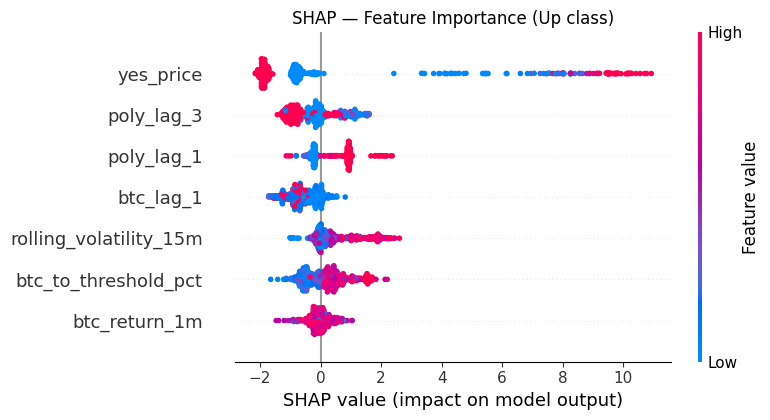

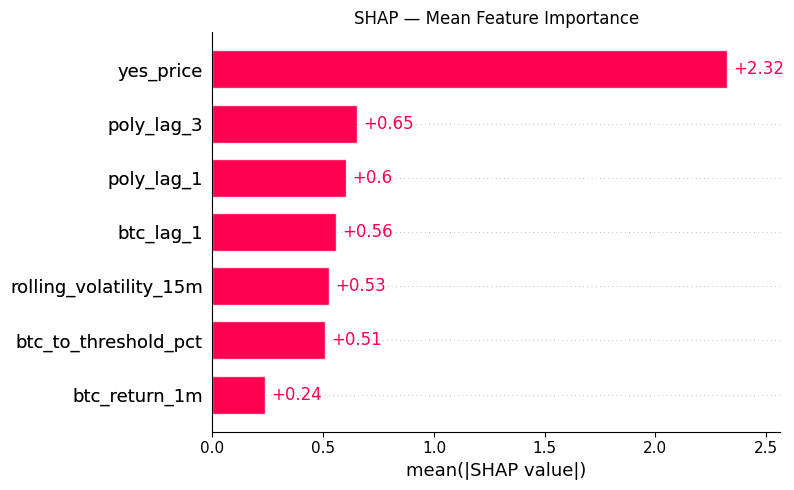

In [9]:
# Beeswarm plot
shap.plots.beeswarm(shap_values, max_display=7, show=False)
plt.title("SHAP â Feature Importance (Up class)")
plt.tight_layout()
plt.savefig("data/processed/plot_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

# Bar plot
shap.plots.bar(shap_values, max_display=7, show=False)
plt.title("SHAP â Mean Feature Importance")
plt.tight_layout()
plt.savefig("data/processed/plot_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
!git config user.email "kadirnsy@gmail.com"
!git config user.name "llelus"
!git pull --rebase origin main
!git push
!git add data/processed/
!git commit -m "add: ML pipeline - LightGBM + SHAP tamamlandi"
!git push

remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 352.53 KiB | 2.94 MiB/s, done.
From https://github.com/llelus/DSA-Project
 * branch            main       -> FETCH_HEAD
   2431e16..3be12d2  main       -> origin/main
Successfully rebased and updated refs/heads/main.
Enumerating objects: 10, done.
Counting objects: 100% (10/10), done.
Delta compression using up to 2 threads
Compressing objects: 100% (7/7), done.
Writing objects: 100% (7/7), 168.77 KiB | 4.22 MiB/s, done.
Total 7 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/llelus/DSA-Project.git
   3be12d2..8b87035  main -> main
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date
